In [1]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [5]:
import pandas as pd

df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 🔍 Key Insights

- A few products generate most of the revenue.
- High-performing categories dominate sales.
- Revenue is concentrated in specific segments.

📊 KPI METRICS
Total Revenue: 456000
Total Orders: 1000
Average Order Value: 456.0


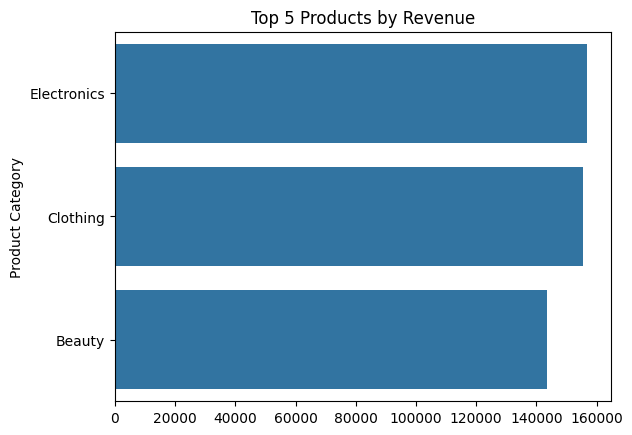

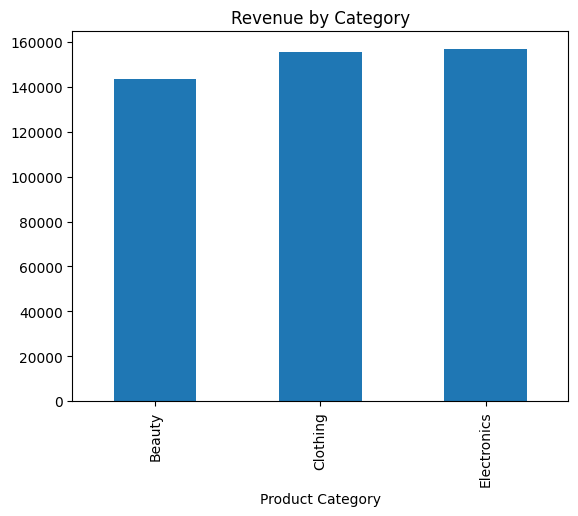

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('retail_sales_dataset.csv')

# Cleaning
df.dropna(inplace=True)

# Auto detect columns
qty = [c for c in df.columns if 'quant' in c.lower()][0]
price = [c for c in df.columns if 'price' in c.lower() or 'sales' in c.lower()][0]

# Revenue
df['Revenue'] = df[qty] * df[price]

# ================= KPI =================
total_revenue = df['Revenue'].sum()
total_orders = len(df)
avg_order_value = total_revenue / total_orders

print("📊 KPI METRICS")
print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value, 2))

# ================= TOP PRODUCTS =================
prod = [c for c in df.columns if 'product' in c.lower() or 'item' in c.lower()][0]

top_products = df.groupby(prod)['Revenue'].sum().sort_values(ascending=False).head(5)

plt.figure()
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 5 Products by Revenue")
plt.show()

# ================= CATEGORY =================
cat_col = None
for col in df.columns:
    if 'category' in col.lower():
        cat_col = col

if cat_col:
    category_sales = df.groupby(cat_col)['Revenue'].sum()

    plt.figure()
    category_sales.plot(kind='bar')
    plt.title("Revenue by Category")
    plt.show()

## 🚀 Business Recommendations

- Focus marketing on top products
- Increase stock for high-demand items
- Improve low-performing categories